# Vocabulary Characteristics Across Albums

In [1]:


import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import ast
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

from lana_nlp.pipeline.create_features import LyricsAnalyzer

In [2]:
df = pd.read_csv("../data/processed/lyrics.csv")

# make sure nlp_cleaned_lyrics is a list of tokens
df["nlp_cleaned_lyrics"] = (
    df["nlp_cleaned_lyrics"]
    .apply(ast.literal_eval)
)

In [3]:
analyzer = LyricsAnalyzer(
    df,
    basic_text_column="basic_cleaned_lyrics",
    nlp_text_column="nlp_cleaned_lyrics",
)

df = analyzer.analyze()

In [4]:
df.head()

,Unnamed: 0,artist,album,song,year,lyrics,basic_cleaned_lyrics,nlp_cleaned_lyrics,word_count,unique_words,syllable_count,line_count,reading_minutes
0,0,Lana Del Rey,Sirens,Drive By,2006,There was a drive-by Sunday night\nMost of us ...,there was a driveby sunday night\nmost of us w...,"[driveby, sunday, night, u, bed, right, turned...",251,95,298,37,1.255
1,1,Lana Del Rey,Sirens,River Road,2006,"Another day is over, another day is done\nAnd ...",another day is over another day is done\nand n...,"[another, day, another, day, done, gettin, clo...",172,65,217,30,0.860
2,2,Lana Del Rey,Sirens,A Star for Nick,2006,"Well, you know it and I know it, I'm gonna be ...",well you know it and i know it I am gonna be a...,"[well, know, know, gon, star, far, say, hello,...",92,45,106,15,0.460
3,3,Lana Del Rey,Sirens,My Momma,2006,My momma wouldn't say you were a nice guy\nBut...,my momma would not say you were a nice guy\nbu...,"[momma, would, say, nice, guy, 40, job, momma,...",303,112,346,37,1.515
4,4,Lana Del Rey,Sirens,Bad Disease,2006,"Well, there's somethin' about watchin' a crime...",well theres somethin about watchin a crime\nth...,"[well, there, somethin, watchin, crime, make, ...",238,107,280,40,1.190


## Vocabulary Size

How large is Lana's vocabulary?

In [5]:
vocabulary_by_album = (
    df.groupby(["album", "year"])["nlp_cleaned_lyrics"]
    .apply(lambda songs: len(set(word for song in songs for word in song)))
    .reset_index(name="vocabulary_size")
)

vocabulary_by_album

,album,year,vocabulary_size
0,Blue Banisters,2021,657
1,Born To Die,2012,791
2,Chemtrails Over the Country Club,2021,493
3,Did You Know That There's a Tunnel Under Ocean...,2023,881
4,Honeymoon,2015,521
5,"Lana Del Ray, A.K.A. Lizzy Grant",2010,385
6,Lust for Life,2016,770
7,Norman Fucking Rockwell!,2019,663
8,Paradise,2012,412
9,Sirens,2006,498


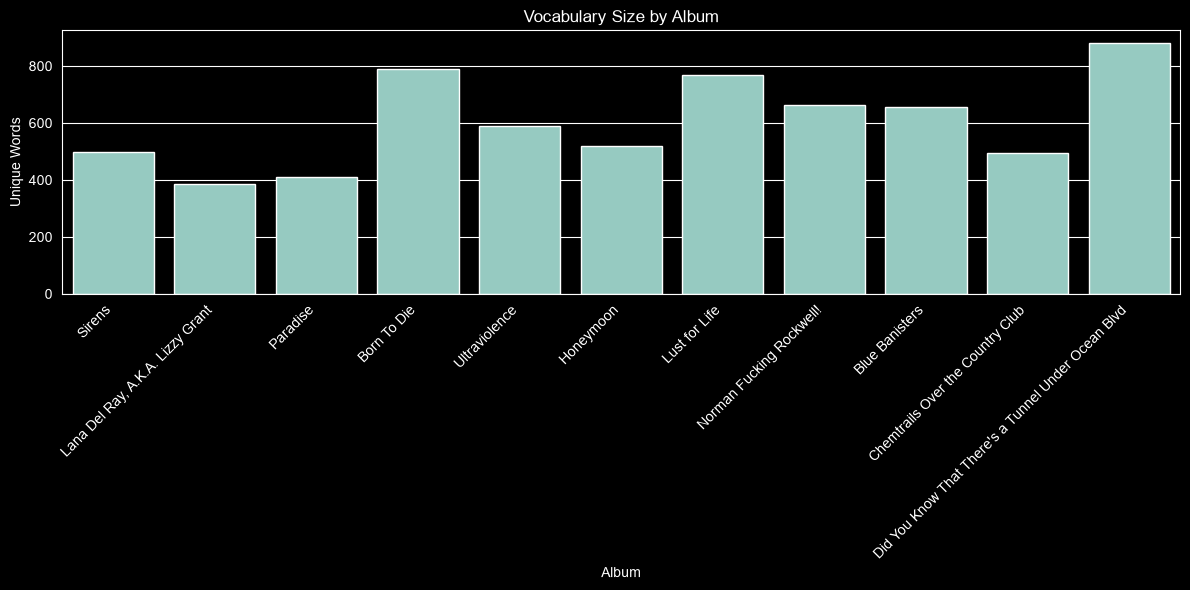

In [6]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=vocabulary_by_album.sort_values("year"),
    x="album",
    y="vocabulary_size"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Album")
plt.ylabel("Unique Words")
plt.title("Vocabulary Size by Album")
plt.tight_layout()
plt.show()

## Repeated Words

How much does Lana repeat herself?

In [7]:
vocabulary_stats = (
    df.groupby(["album", "year"])["nlp_cleaned_lyrics"]
    .apply(
        lambda songs: [
            word
            for song in songs
            for word in song
        ]
    )
    .reset_index(name="all_words")
)

# Total number of word occurrences
vocabulary_stats["total_words"] = (
    vocabulary_stats["all_words"]
    .apply(len)
)

# Number of unique words
vocabulary_stats["vocabulary_size"] = (
    vocabulary_stats["all_words"]
    .apply(lambda words: len(set(words)))
)

# Repitition Rate
vocabulary_stats["repetition_rate"] = (
    1
    - vocabulary_stats["vocabulary_size"]
    / vocabulary_stats["total_words"]
)

vocabulary_stats[
    [
        "album",
        "year",
        "total_words",
        "vocabulary_size",
        "repetition_rate"
    ]
].sort_values("year")

,album,year,total_words,vocabulary_size,repetition_rate
9,Sirens,2006,1292,498,0.614551
5,"Lana Del Ray, A.K.A. Lizzy Grant",2010,1486,385,0.740915
8,Paradise,2012,1253,412,0.671189
1,Born To Die,2012,2857,791,0.723136
10,Ultraviolence,2014,2065,589,0.714770
4,Honeymoon,2015,1723,521,0.697620
6,Lust for Life,2016,2646,770,0.708995
7,Norman Fucking Rockwell!,2019,2054,663,0.677215
0,Blue Banisters,2021,1913,657,0.656560
2,Chemtrails Over the Country Club,2021,1500,493,0.671333


In [8]:
# See the repeated words
def get_word_frequencies(words):
    return Counter(words)

In [9]:
album_word_counts = {}

for _, row in vocabulary_stats.iterrows():
    album_word_counts[row["album"]] = Counter(row["all_words"])

album_word_counts["Born To Die"].most_common(20)

[('love', 74),
 ('baby', 73),
 ('know', 38),
 ('say', 30),
 ('think', 30),
 ('cause', 27),
 ('tell', 26),
 ('time', 26),
 ('girl', 25),
 ('want', 25),
 ('boy', 25),
 ('summertime', 25),
 ('hey', 24),
 ('got', 23),
 ('take', 23),
 ('good', 23),
 ('well', 23),
 ('die', 22),
 ('anthem', 22),
 ('life', 21)]

## Most Frequent Words

What words does she use the most?

In [10]:
# Get the top words
top_words_by_album = {}

for _, row in vocabulary_stats.iterrows():
    top_words_by_album[row["album"]] = (
        Counter(row["all_words"]).most_common(15)
    )

In [11]:
print(top_words_by_album["Born To Die"])

[('love', 74), ('baby', 73), ('know', 38), ('say', 30), ('think', 30), ('cause', 27), ('tell', 26), ('time', 26), ('girl', 25), ('want', 25), ('boy', 25), ('summertime', 25), ('hey', 24), ('got', 23), ('take', 23)]


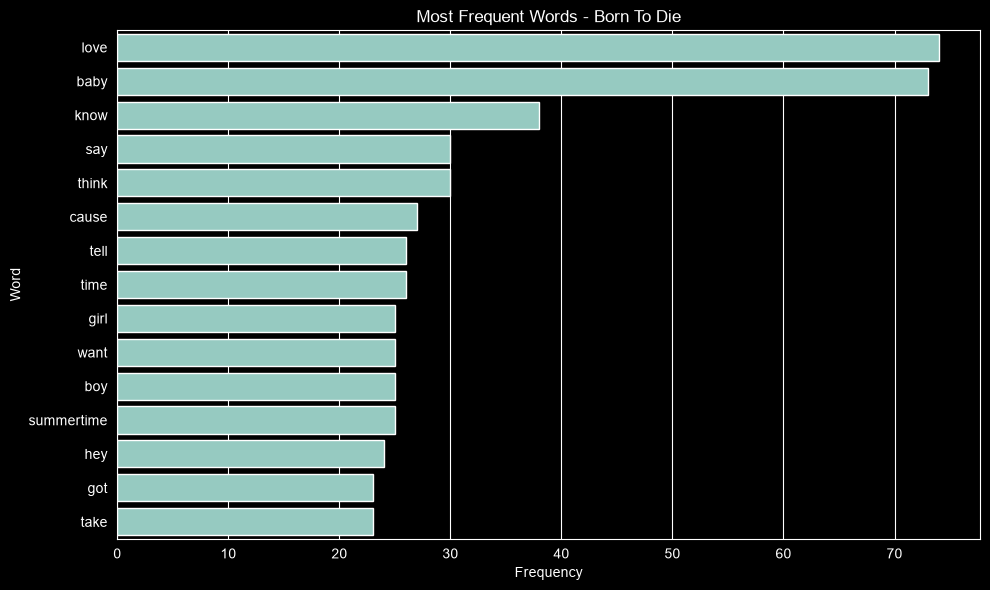

In [12]:
album = "Born To Die"

word_counts = (
    Counter(vocabulary_stats.loc[
        vocabulary_stats["album"] == album,
        "all_words"
        ].iloc[0]
    )
)

top_words = word_counts.most_common(15)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=counts,
    y=words
)

plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title(f"Most Frequent Words - {album}")
plt.tight_layout()
plt.show()

In [13]:
# Dataframe with top words from every album
top_words_df = []

for _, row in vocabulary_stats.iterrows():

    counts = Counter(row["all_words"])

    for word, count in counts.most_common(15):
        top_words_df.append({
            "album": row["album"],
            "year": row["year"],
            "word": word,
            "frequency": count
        })

top_words_df = pd.DataFrame(top_words_df)

top_words_df

,album,year,word,frequency
0,Blue Banisters,2021,baby,40
1,Blue Banisters,2021,know,29
2,Blue Banisters,2021,blue,25
3,Blue Banisters,2021,burn,24
4,Blue Banisters,2021,cause,23
...,...,...,...,...
160,Ultraviolence,2014,come,22
161,Ultraviolence,2014,cry,22
162,Ultraviolence,2014,know,20
163,Ultraviolence,2014,side,19


In [14]:
top_words_df[
    top_words_df["album"] == "Did You Know That There's a Tunnel Under Ocean Blvd"
]

,album,year,word,frequency
45,Did You Know That There's a Tunnel Under Ocean...,2023,know,71
46,Did You Know That There's a Tunnel Under Ocean...,2023,love,62
47,Did You Know That There's a Tunnel Under Ocean...,2023,jimmy,37
48,Did You Know That There's a Tunnel Under Ocean...,2023,say,30
49,Did You Know That There's a Tunnel Under Ocean...,2023,light,30
50,Did You Know That There's a Tunnel Under Ocean...,2023,back,28
51,Did You Know That There's a Tunnel Under Ocean...,2023,baby,28
52,Did You Know That There's a Tunnel Under Ocean...,2023,hand,28
53,Did You Know That There's a Tunnel Under Ocean...,2023,gon,26
54,Did You Know That There's a Tunnel Under Ocean...,2023,cause,25


## What Words Make Each Album Lyrically Distinctive?

In [15]:
album_documents = (
    df.groupby(["album", "year"])["nlp_cleaned_lyrics"]
    .apply(lambda songs: " ".join(
        word
        for song in songs
        for word in song
    ))
    .reset_index(name="document")
)

album_documents

,album,year,document
0,Blue Banisters,2021,guess could call text book lookin father wante...
1,Born To Die,2012,got louder got foot fail take finish line hear...
2,Chemtrails Over the Country Club,2021,sun stare care head hand thinking simpler time...
3,Did You Know That There's a Tunnel Under Ocean...,2023,one two ready gon take mind mine say mine than...
4,Honeymoon,2015,know fashionable love go cause truly there nob...
5,"Lana Del Ray, A.K.A. Lizzy Grant",2010,bound stair shower know goin leave know goin l...
6,Lust for Life,2016,look kid vintage music coming satellite cruisi...
7,Norman Fucking Rockwell!,2019,goddamn manchild fucked good almost said love ...
8,Paradise,2012,oohoohoohooh oohoohooh oohoohoohooh oohoohooh ...
9,Sirens,2006,driveby sunday night u bed right turned light ...


In [16]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(
    album_documents["document"]
)

feature_names = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=album_documents["album"],
    columns=feature_names
)

tfidf_df

,11,13,16,17,18th,205,24,247,2am,300,...,yesterday,yet,yo,yoko,york,young,yourе,youth,yеah,zoom
album,,,,,,,,,,,,,,,,,,,,,
Blue Banisters,0.016308,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016308,...,0.016308,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016308
Born To Die,0.000000,0.000000,0.022092,0.011046,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.006089,0.014841,0.000000,0.066785,0.000000,0.000000,0.000000,0.000000,0.000000
Chemtrails Over the Country Club,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.008561,0.000000,0.000000,0.000000,0.000000
Did You Know That There's a Tunnel Under Ocean Blvd,0.000000,0.000000,0.000000,0.000000,0.010243,0.010243,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.005647,0.006881,0.000000,0.000000,0.023622,0.010243,0.000000,0.010243,0.000000
Honeymoon,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.095544,0.000000,0.000000,0.000000,...,0.000000,0.008778,0.000000,0.000000,0.000000,0.007345,0.000000,0.000000,0.000000,0.000000
"Lana Del Ray, A.K.A. Lizzy Grant",0.000000,0.010208,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.006857,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Lust for Life,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.011899,0.000000,0.043905,0.000000,0.020341,0.000000,0.000000
Norman Fucking Rockwell!,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.031102,0.015551,0.000000,...,0.000000,0.025718,0.000000,0.000000,0.020894,0.007173,0.000000,0.000000,0.000000,0.000000
Paradise,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.037000,0.000000,0.000000,0.000000,0.000000


In [17]:
tfidf_top_words_df = []

for album in tfidf_df.index:

    top_words = (
        tfidf_df.loc[album]
        .sort_values(ascending=False)
        .head(15)
    )

    for word, score in top_words.items():
        tfidf_top_words_df.append({
            "album": album,
            "word": word,
            "tfidf": score
        })

tfidf_top_words_df = pd.DataFrame(tfidf_top_words_df)

tfidf_top_words_df

,album,word,tfidf
0,Blue Banisters,burn,0.262930
1,Blue Banisters,baby,0.233657
2,Blue Banisters,know,0.169401
3,Blue Banisters,lie,0.155989
4,Blue Banisters,beautiful,0.147779
...,...,...,...
160,Ultraviolence,pretty,0.178055
161,Ultraviolence,cry,0.153192
162,Ultraviolence,beauty,0.127285
163,Ultraviolence,loved,0.113943


In [18]:
tfidf_top_words_df[
    tfidf_top_words_df["album"] == "Did You Know That There's a Tunnel Under Ocean Blvd"
]

,album,word,tfidf
45,Did You Know That There's a Tunnel Under Ocean...,jimmy,0.378988
46,Did You Know That There's a Tunnel Under Ocean...,know,0.260498
47,Did You Know That There's a Tunnel Under Ocean...,love,0.227477
48,Did You Know That There's a Tunnel Under Ocean...,necklace,0.204858
49,Did You Know That There's a Tunnel Under Ocean...,candy,0.175105
50,Did You Know That There's a Tunnel Under Ocean...,knee,0.172026
51,Did You Know That There's a Tunnel Under Ocean...,jolie,0.163887
52,Did You Know That There's a Tunnel Under Ocean...,angelina,0.140084
53,Did You Know That There's a Tunnel Under Ocean...,bang,0.137621
54,Did You Know That There's a Tunnel Under Ocean...,braid,0.131329


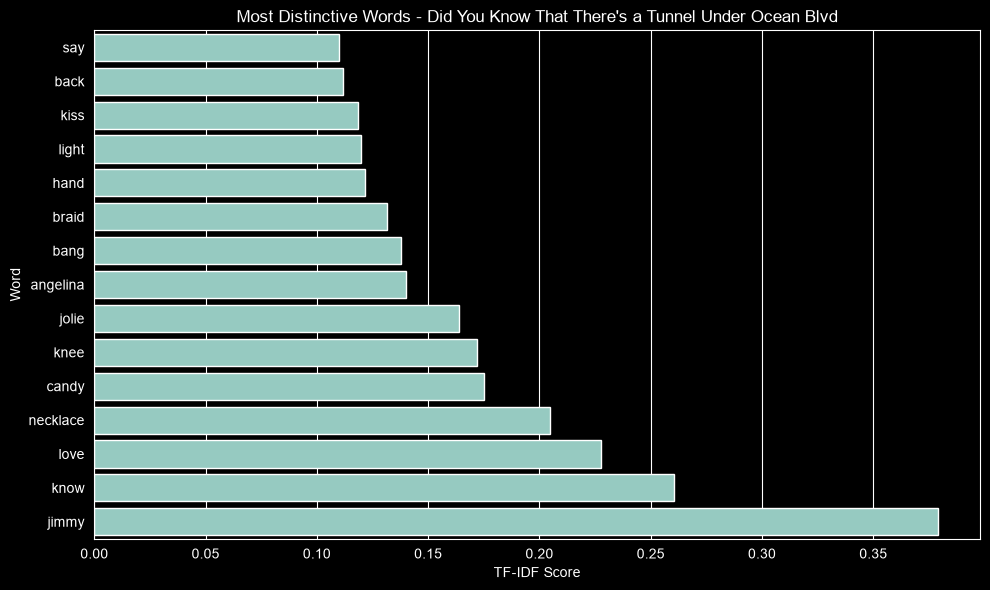

In [32]:
album = "Did You Know That There's a Tunnel Under Ocean Blvd"

plot_data = (
    tfidf_top_words_df[
        tfidf_top_words_df["album"] == album
    ]
    .sort_values("tfidf")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="tfidf",
    y="word"
)

plt.xlabel("TF-IDF Score")
plt.ylabel("Word")
plt.title(f"Most Distinctive Words - {album}")
plt.tight_layout()
plt.show()

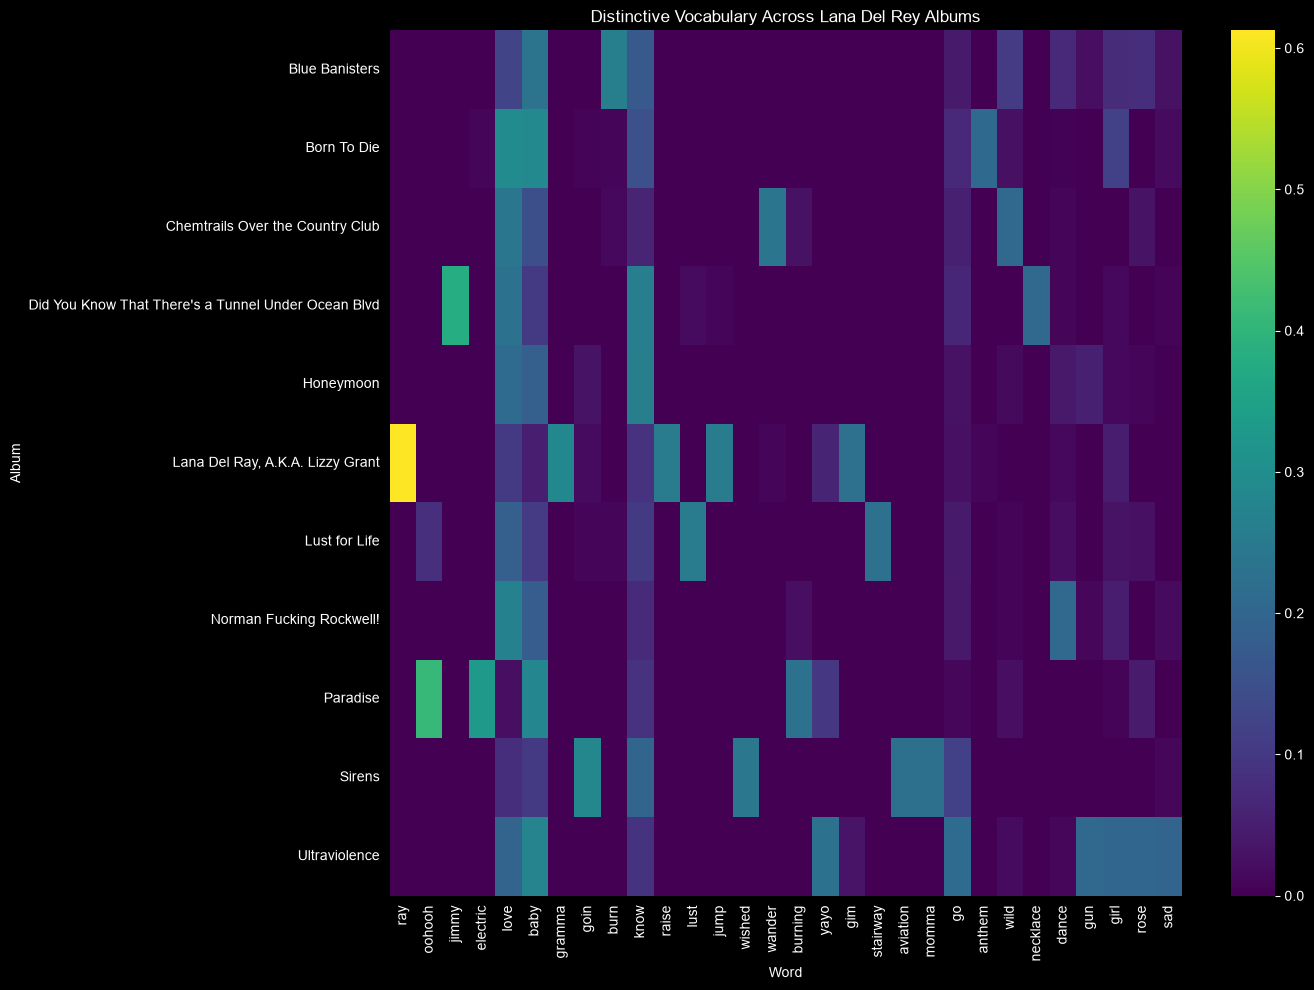

In [20]:
# Take most distinctive word and put them into a matrix
top_words = (
    tfidf_top_words_df
    .groupby("word")["tfidf"]
    .max()
    .sort_values(ascending=False)
    .head(30)
    .index
)

tfidf_heatmap = tfidf_df[top_words]

plt.figure(figsize=(14, 10))

sns.heatmap(
    tfidf_heatmap,
    annot=False,
    cmap="viridis"
)

plt.xlabel("Word")
plt.ylabel("Album")
plt.title("Distinctive Vocabulary Across Lana Del Rey Albums")
plt.tight_layout()
plt.show()


In [21]:
all_words = [
    word
    for song in df["nlp_cleaned_lyrics"]
    for word in song
]

Counter(all_words).most_common(50)

[('love', 407),
 ('baby', 390),
 ('know', 316),
 ('got', 231),
 ('cause', 192),
 ('say', 167),
 ('take', 161),
 ('go', 145),
 ('come', 143),
 ('one', 136),
 ('make', 133),
 ('want', 129),
 ('time', 127),
 ('would', 127),
 ('life', 127),
 ('god', 124),
 ('blue', 124),
 ('light', 123),
 ('feel', 117),
 ('think', 107),
 ('never', 107),
 ('man', 106),
 ('back', 104),
 ('girl', 104),
 ('way', 102),
 ('there', 100),
 ('could', 96),
 ('said', 94),
 ('thing', 93),
 ('put', 92),
 ('thats', 87),
 ('crazy', 85),
 ('tell', 85),
 ('gon', 82),
 ('keep', 82),
 ('high', 82),
 ('see', 77),
 ('white', 75),
 ('little', 74),
 ('well', 74),
 ('night', 72),
 ('good', 71),
 ('beautiful', 71),
 ('right', 70),
 ('look', 70),
 ('leave', 65),
 ('pretty', 65),
 ('boy', 65),
 ('really', 64),
 ('day', 63)]